## Imports and DataFrame initialization

Here we load the dataset and provide optional filtering to get best sample images possible.

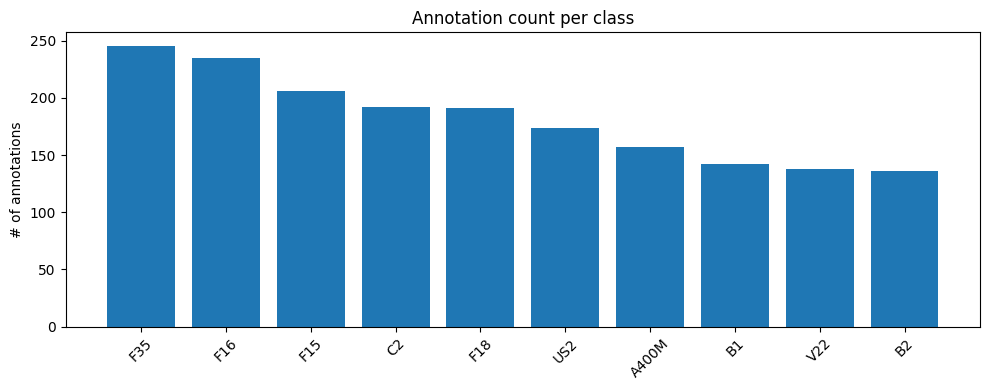

,filename,width,height,class,xmin,ymin,xmax,ymax,image_path,csv_path
0,000106393cfe2343888c584e65fd2274,3520,2514,F16,0,0,1796,1451,/Users/f1ol/workspace/ukma/NNs/LAB1/aircraft_d...,/Users/f1ol/workspace/ukma/NNs/LAB1/aircraft_d...
1,000aa01b25574f28b654718db0700f72,2048,1365,F35,852,177,1998,503,/Users/f1ol/workspace/ukma/NNs/LAB1/aircraft_d...,/Users/f1ol/workspace/ukma/NNs/LAB1/aircraft_d...
2,000e7662268a1071827c5a8663e773f9,1200,856,US2,522,240,1200,497,/Users/f1ol/workspace/ukma/NNs/LAB1/aircraft_d...,/Users/f1ol/workspace/ukma/NNs/LAB1/aircraft_d...
3,0039eb1ff33d29c55f943e05730bb259,900,600,C2,122,192,721,400,/Users/f1ol/workspace/ukma/NNs/LAB1/aircraft_d...,/Users/f1ol/workspace/ukma/NNs/LAB1/aircraft_d...
4,0052ebf62f5f24c027a08b99ab00c9b9,1200,900,F18,356,354,763,575,/Users/f1ol/workspace/ukma/NNs/LAB1/aircraft_d...,/Users/f1ol/workspace/ukma/NNs/LAB1/aircraft_d...


In [ ]:
from typing import Dict, List, Optional, Tuple

import math
import random

import pandas as pd
import torch
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import tv_tensors
from torchvision.transforms import v2
from torchvision.transforms.v2 import functional as F_v2

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm.auto import tqdm

from dataset_loader import load_aircraft_dataset

#TARGET_CLASSES = ["F22", "Mig31", "Su34", "Su57", "Tu95", "Tu160", "Mirage2000"]
TARGET_CLASSES = ["F35", "F15", "F16", "C2", "US2", "F18", "A400M", "B1", "B2", "V22"]

aircraft_df = load_aircraft_dataset(
    allowed_classes=TARGET_CLASSES,
    area_range=(0.05, 0.3),
    allow_multiple_annotations=False,
)


# Show classes distribution in dataframe

In [ ]:
top_k = 20
class_counts = aircraft_df["class"].value_counts()
top_counts = class_counts.head(top_k)
plt.figure(figsize=(10, 4))
plt.bar(top_counts.index, top_counts.values, color="tab:blue")
plt.ylabel("# of annotations")
plt.title("Annotation count per class")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

aircraft_df.head()

## Display 1 sample image per class

In [ ]:
def plot_sample(group):
    image_path = group["image_path"].iloc[0]
    if not image_path:
        print(f"No image path found for {group['filename'].iloc[0]}.")
        return

    image = plt.imread(image_path)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(image)

    for _, row in group.iterrows():
        width = row["xmax"] - row["xmin"]
        height = row["ymax"] - row["ymin"]
        rect = patches.Rectangle(
            (row["xmin"], row["ymin"]),
            width,
            height,
            linewidth=2,
            edgecolor="lime",
            facecolor="none",
        )
        ax.add_patch(rect)
        ax.text(
            row["xmin"],
            max(row["ymin"] - 5, 0),
            row["class"],
            color="white",
            fontsize=10,
            bbox=dict(facecolor="black", alpha=0.6, pad=1),
        )

    ax.set_title(f"{group['filename'].iloc[0]}")
    ax.axis("off")
    plt.show()


valid_groups = [group for _, group in aircraft_df.groupby("filename") if group["image_path"].notna().all()]

random_samples_by_class = {}
for cls_name in aircraft_df["class"].unique():
    class_groups = [group for group in valid_groups if group["class"].iloc[0] == cls_name]
    if class_groups:
        random_samples_by_class[cls_name] = random.choice(class_groups)

for cls_name, group in random_samples_by_class.items():
    print(f"Class: {cls_name}")
    plot_sample(group)


### Augmentation Strategy Rationale
- **AlexNet detector:** We preserve the ImageNet-style normalization and center crop after modest geometric jitter because the backbone expects 227×227 receptive fields and benefits from mild photometric noise without heavy spatial distortion [Krizhevsky et al., 2012](https://proceedings.neurips.cc/paper_files/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf).
- **R-CNN:** The pipeline learns from warped region proposals, so `RandomIoUCrop` plus horizontal flips emulate positive/negative proposal variety while keeping the 224×224 warping used in selective-search training [Girshick et al., 2014](https://arxiv.org/pdf/1311.2524).
- **YOLO v1:** Training thrives on aggressive scale and aspect variation while maintaining the 448×448 grid input; combining IoU-aware crops, zoom-out padding, and color jitter keeps boxes consistent with the dense grid predictions [Redmon et al., 2016](https://arxiv.org/pdf/1506.02640).



Later we refused from data augumentation steps, to make things more simple. This step only resizes images to align with model's input. 

In [ ]:
# Label encoding
class_names: List[str] = sorted(aircraft_df["class"].unique())
class_to_idx: Dict[str, int] = {cls_name: idx for idx, cls_name in enumerate(class_names)}


def split_dataframe_by_filename(
    df: pd.DataFrame,
    ratios: Tuple[float, float, float] = (0.7, 0.15, 0.15),
    seed: int = 42,
) -> Dict[str, pd.DataFrame]:
    """Return deterministic train/val/test splits grouped by filename."""

    if len(ratios) != 3:
        raise ValueError("ratios must contain exactly three values for train/val/test.")
    if any(r <= 0 for r in ratios):
        raise ValueError("ratios must be positive.")

    total_ratio = sum(ratios)
    normalized = [r / total_ratio for r in ratios]

    filenames = sorted(df["filename"].unique())
    if len(filenames) < 3:
        raise ValueError("Need at least three distinct images to perform train/val/test split.")

    generator = torch.Generator().manual_seed(seed)
    permutation = torch.randperm(len(filenames), generator=generator).tolist()

    total = len(filenames)
    counts = [int(total * r) for r in normalized]
    remainder = total - sum(counts)
    for i in range(remainder):
        counts[i % len(counts)] += 1

    if total >= 3:
        for idx, count in enumerate(counts):
            if count == 0:
                largest = max(range(len(counts)), key=lambda j: counts[j])
                if counts[largest] > 1:
                    counts[largest] -= 1
                    counts[idx] += 1

    train_end = counts[0]
    val_end = train_end + counts[1]

    train_files = {filenames[permutation[i]] for i in range(train_end)}
    val_files = {filenames[permutation[i]] for i in range(train_end, val_end)}
    test_files = {filenames[permutation[i]] for i in range(val_end, total)}

    return {
        "train": df[df["filename"].isin(train_files)].reset_index(drop=True),
        "val": df[df["filename"].isin(val_files)].reset_index(drop=True),
        "test": df[df["filename"].isin(test_files)].reset_index(drop=True),
    }


def ensure_rgb(image_path: str) -> Image.Image:
    image = Image.open(image_path)
    if image.mode != "RGB":
        image = image.convert("RGB")
    return image


class AircraftDetectionDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, class_to_idx: Dict[str, int], transforms=None) -> None:
        self.class_to_idx = class_to_idx
        self.transforms = transforms
        self.groups = [
            group.reset_index(drop=True)
            for _, group in dataframe.groupby("filename")
            if group["image_path"].notna().all()
        ]

    def __len__(self) -> int:
        return len(self.groups)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        annotations = self.groups[idx]
        image_path = annotations["image_path"].iloc[0]
        image = ensure_rgb(image_path)

        boxes = torch.tensor(
            annotations[["xmin", "ymin", "xmax", "ymax"]].values,
            dtype=torch.float32,
        )
        labels = torch.tensor(
            [self.class_to_idx[label] for label in annotations["class"]],
            dtype=torch.int64,
        )

        sample = {
            "image": image,
            "boxes": tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=image.size[::-1]),
            "labels": labels,
            "image_id": annotations["filename"].iloc[0],
        }

        if self.transforms is not None:
            sample = self.transforms(sample)

        return sample


split_dfs = split_dataframe_by_filename(aircraft_df)
print("Base split sizes:", {split: len(df) for split, df in split_dfs.items()})

imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std = (0.229, 0.224, 0.225)

common_preprocess = [v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]

alexnet_train_transforms = v2.Compose(
    common_preprocess
    + [
        v2.Resize((256, 256), antialias=True),
        #v2.RandomHorizontalFlip(p=0.5),
        # v2.RandomPhotometricDistort(hue=(-0.04, 0.04)),
        #v2.RandomAffine(
        #    degrees=5,
        #    translate=(0.05, 0.05),
        #    scale=(0.9, 1.1),
        #    interpolation=v2.InterpolationMode.BILINEAR,
        #    fill=imagenet_mean,
        #),
        v2.CenterCrop((227, 227)),
        v2.Normalize(mean=imagenet_mean, std=imagenet_std),
    ]
)

alexnet_eval_transforms = v2.Compose(
    common_preprocess
    + [
        v2.Resize((256, 256), antialias=True),
        v2.CenterCrop((227, 227)),
        v2.Normalize(mean=imagenet_mean, std=imagenet_std),
    ]
)

rcnn_train_transforms = v2.Compose(
    common_preprocess
    + [
        #v2.RandomIoUCrop(min_scale=0.3, max_scale=1.0),
        v2.Resize((224, 224), antialias=True),
        # v2.RandomHorizontalFlip(p=0.5),
        #v2.RandomPhotometricDistort(hue=(-0.04, 0.04)),
        v2.Normalize(mean=imagenet_mean, std=imagenet_std),
    ]
)

rcnn_eval_transforms = v2.Compose(
    common_preprocess
    + [
        v2.Resize((224, 224), antialias=True),
        v2.Normalize(mean=imagenet_mean, std=imagenet_std),
    ]
)

yolo_train_transforms = v2.Compose(
    common_preprocess
    + [
        #v2.RandomIoUCrop(min_scale=0.4, max_scale=1.0),
        #v2.RandomZoomOut(p=0.5, fill=imagenet_mean),
        #v2.RandomHorizontalFlip(p=0.5),
        #v2.RandomPhotometricDistort(hue=(-0.04, 0.04)),
        v2.Resize((448, 448), antialias=True),
        v2.Normalize(mean=imagenet_mean, std=imagenet_std),
    ]
)

yolo_eval_transforms = v2.Compose(
    common_preprocess
    + [
        v2.Resize((448, 448), antialias=True),
        v2.Normalize(mean=imagenet_mean, std=imagenet_std),
    ]
)

transform_registry = {
    "alexnet": {"train": alexnet_train_transforms, "val": alexnet_eval_transforms, "test": alexnet_eval_transforms},
    "rcnn": {"train": rcnn_train_transforms, "val": rcnn_eval_transforms, "test": rcnn_eval_transforms},
    "yolo": {"train": yolo_train_transforms, "val": yolo_eval_transforms, "test": yolo_eval_transforms},
}

datasets = {
    model_name: {
        split: AircraftDetectionDataset(split_dfs[split], class_to_idx, transforms)
        for split, transforms in splits.items()
    }
    for model_name, splits in transform_registry.items()
}

for model_name, splits in datasets.items():
    summary = {split: len(dataset) for split, dataset in splits.items()}
    print(f"{model_name}: {summary}")



## Display example of augumented images per model

In [ ]:
import random
from torchvision.utils import draw_bounding_boxes

random.seed(31)
torch.manual_seed(31)

model_order = ["alexnet", "rcnn", "yolo"]


def tensor_to_numpy_image(image_tensor: torch.Tensor) -> torch.Tensor:
    image = image_tensor.detach().clone()
    mean = torch.tensor(imagenet_mean, device=image_tensor.device).view(3, 1, 1)
    std = torch.tensor(imagenet_std, device=image_tensor.device).view(3, 1, 1)
    image = image * std + mean
    return image.clamp(0, 1)


def get_sample_by_id(dataset: AircraftDetectionDataset, image_id: str) -> Dict[str, torch.Tensor]:
    for idx, group in enumerate(dataset.groups):
        if group["filename"].iloc[0] == image_id:
            return dataset[idx]
    raise KeyError(f"Image id {image_id} not found in dataset.")


class_to_image_id: Dict[str, str] = {}
base_groups = datasets["alexnet"]["train"].groups
for cls_name in class_names:
    cls_groups = [group for group in base_groups if cls_name in group["class"].values]
    if cls_groups:
        class_to_image_id[cls_name] = random.choice(cls_groups)["filename"].iloc[0]

rows = len(class_to_image_id)
cols = len(model_order)
if rows == 0:
    raise RuntimeError("No classes available in the dataset to visualize augmentations.")

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 3.5 * rows))

if rows == 1 and cols == 1:
    axes = [[axes]]
elif rows == 1:
    axes = [axes]
elif cols == 1:
    axes = [[ax] for ax in axes]

for row_idx, (cls_name, image_id) in enumerate(class_to_image_id.items()):
    for col_idx, model_name in enumerate(model_order):
        ax = axes[row_idx][col_idx]
        dataset = datasets[model_name]["train"]
        try:
            augmented_sample = get_sample_by_id(dataset, image_id)
        except KeyError:
            ax.axis("off")
            ax.set_title(f"{cls_name} - {model_name.upper()}\nSample missing")
            continue

        image_tensor = augmented_sample["image"].cpu()
        boxes = augmented_sample["boxes"].to(torch.float32)
        labels = augmented_sample["labels"].cpu()

        boxes_tensor = boxes.as_subclass(torch.Tensor) if hasattr(boxes, "as_subclass") else torch.as_tensor(boxes)
        rgb_image = tensor_to_numpy_image(image_tensor)

        label_strings = [class_names[label] for label in labels]
        drawn = draw_bounding_boxes((rgb_image * 255).to(torch.uint8), boxes_tensor, labels=label_strings, colors="lime")

        ax.imshow(drawn.permute(1, 2, 0))
        height, width = image_tensor.shape[1:]
        ax.set_title(f"{cls_name} — {model_name.upper()}\n{image_id}\n{width}×{height}")
        ax.axis("off")

plt.tight_layout()
plt.show()



The large borders you’re seeing on the YOLO sample image are a deliberate effect of RandomZoomOut. It mimics objects that occupy only a small portion of the frame, which the original YOLO paper relied on to improve recall of small objects. The padding won’t harm training—YOLO expects some cells to be empty—but.

## Setup for training

In [ ]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")


def detection_collate(batch):
    return batch


def make_dataloader(dataset, batch_size: int, shuffle: bool = True) -> DataLoader:
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        collate_fn=detection_collate,
        drop_last=False,
    )



## Train AlexNet model with object detection

1. At first we tried to limit the amount of classes to simplify the task , since original dataset contained 95 classes. Now we focus on following classes: ["F16", "F35", "F22", "Mig31", "Su34", "Su57", "Tu95", "Tu160", "Mirage2000"].
2. Then, apparently, dataset appeared to be very unbalanced, leaning to the "F16", so it called every single plane as F16. We had to rebalance it for every batch taken for the training.
3. After balancing the training batches, the model started calling every other plane as F16 or F22 - 2 dominating classes in the focused set. 

In [ ]:
from models.alexnet_detector import AlexNetDetector


def prepare_alexnet_batch(
    batch,
    device: torch.device,
    boxes_per_image: int = 3,
    target_batch_size: int = 32,
):
    """Expand each image into multiple samples and balance class counts per batch."""

    class_entries: Dict[int, list[Tuple[torch.Tensor, torch.Tensor, torch.Tensor]]] = {}

    for sample in batch:
        boxes = torch.as_tensor(sample["boxes"], device=device)
        labels = torch.as_tensor(sample["labels"], device=device)
        image = torch.as_tensor(sample["image"], device=device)

        if boxes.numel() == 0:
            continue

        height, width = image.shape[1:]
        selection_count = min(boxes_per_image, len(boxes))
        selected_indices = torch.randperm(len(boxes), device=device)[:selection_count]

        for idx in selected_indices:
            bbox = boxes[idx]
            label = labels[idx]

            bbox_norm = bbox.clone()
            bbox_norm[0::2] /= width
            bbox_norm[1::2] /= height

            class_entries.setdefault(int(label.item()), []).append(
                (image.clone(), label.clone(), bbox_norm)
            )

    if not class_entries:
        return None

    classes_present = list(class_entries.keys())
    per_class_quota = max(1, target_batch_size // len(classes_present))

    images_balanced: list[torch.Tensor] = []
    labels_balanced: list[torch.Tensor] = []
    bboxes_balanced: list[torch.Tensor] = []

    for cls, items in class_entries.items():
        if len(items) >= per_class_quota:
            sampled = random.sample(items, per_class_quota)
        else:
            sampled = items.copy()
            while len(sampled) < per_class_quota:
                sampled.append(random.choice(items))

        for image_tensor, label_tensor, bbox_tensor in sampled:
            images_balanced.append(image_tensor)
            labels_balanced.append(label_tensor)
            bboxes_balanced.append(bbox_tensor)

    max_allowed = target_batch_size
    if len(images_balanced) > max_allowed:
        selected_indices = random.sample(range(len(images_balanced)), max_allowed)
        images_balanced = [images_balanced[i] for i in selected_indices]
        labels_balanced = [labels_balanced[i] for i in selected_indices]
        bboxes_balanced = [bboxes_balanced[i] for i in selected_indices]

    return (
        torch.stack(images_balanced),
        torch.stack(labels_balanced),
        torch.stack(bboxes_balanced),
    )


alexnet_model = AlexNetDetector(num_classes=len(class_names)).to(device)
alexnet_optimizer = torch.optim.SGD(alexnet_model.parameters(), lr=1e-1, momentum=0.8, weight_decay=5e-4)
alexnet_scheduler = torch.optim.lr_scheduler.StepLR(alexnet_optimizer, step_size=5, gamma=0.1)
cls_loss_fn = torch.nn.CrossEntropyLoss()
bbox_loss_fn = torch.nn.SmoothL1Loss()

alexnet_train_loader = make_dataloader(datasets["alexnet"]["train"], batch_size=16, shuffle=True)
alexnet_val_loader = make_dataloader(datasets["alexnet"]["val"], batch_size=16, shuffle=False)

alexnet_history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
num_epochs = 10
lambda_bbox = 5.0

for epoch in range(1, num_epochs + 1):
    alexnet_model.train()
    running_loss = 0.0
    sample_count = 0
    correct_cls = 0
    total_cls = 0
    for batch in tqdm(alexnet_train_loader, desc=f"AlexNet Epoch {epoch}/{num_epochs}"):
        prepared = prepare_alexnet_batch(batch, device, boxes_per_image=3, target_batch_size=32)
        if prepared is None:
            continue
        images, cls_targets, bbox_targets = prepared
        alexnet_optimizer.zero_grad()
        outputs = alexnet_model(images)
        logits = outputs.logits
        bbox_deltas = outputs.bbox_deltas
        if alexnet_model.bbox_per_class:
            bbox_deltas = bbox_deltas[torch.arange(len(cls_targets), device=device), cls_targets]
        loss_cls = cls_loss_fn(logits, cls_targets)
        loss_bbox = bbox_loss_fn(bbox_deltas, bbox_targets)
        loss = loss_cls + lambda_bbox * loss_bbox
        loss.backward()
        alexnet_optimizer.step()

        preds = logits.argmax(dim=1)
        correct_cls += (preds == cls_targets).sum().item()
        total_cls += cls_targets.size(0)

        running_loss += loss.item() * images.size(0)
        sample_count += images.size(0)

    epoch_train_loss = running_loss / max(sample_count, 1)
    epoch_train_acc = correct_cls / max(total_cls, 1)
    alexnet_history["train_loss"].append(epoch_train_loss)
    alexnet_history["train_acc"].append(epoch_train_acc)

    alexnet_model.eval()
    val_loss = 0.0
    val_count = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for batch in alexnet_val_loader:
            prepared = prepare_alexnet_batch(batch, device, boxes_per_image=3, target_batch_size=32)
            if prepared is None:
                continue
            images, cls_targets, bbox_targets = prepared
            outputs = alexnet_model(images)
            logits = outputs.logits
            bbox_deltas = outputs.bbox_deltas
            if alexnet_model.bbox_per_class:
                bbox_deltas = bbox_deltas[torch.arange(len(cls_targets), device=device), cls_targets]
            loss_cls = cls_loss_fn(logits, cls_targets)
            loss_bbox = bbox_loss_fn(bbox_deltas, bbox_targets)
            loss = loss_cls + lambda_bbox * loss_bbox
            val_loss += loss.item() * images.size(0)
            val_count += images.size(0)

            preds = logits.argmax(dim=1)
            val_correct += (preds == cls_targets).sum().item()
            val_total += cls_targets.size(0)

    epoch_val_loss = val_loss / max(val_count, 1)
    epoch_val_acc = val_correct / max(val_total, 1)
    alexnet_history["val_loss"].append(epoch_val_loss)
    alexnet_history["val_acc"].append(epoch_val_acc)
    alexnet_scheduler.step()

    print(f"Epoch {epoch}: train_loss={epoch_train_loss:.4f} val_loss={epoch_val_loss:.4f} train_acc={epoch_train_acc:.3f} val_acc={epoch_val_acc:.3f}")

plt.figure(figsize=(6, 4))
plt.plot(alexnet_history["train_loss"], label="Train loss")
plt.plot(alexnet_history["val_loss"], label="Val loss")
plt.title("AlexNet detector training curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(alexnet_history["train_acc"], label="Train acc")
plt.plot(alexnet_history["val_acc"], label="Val acc")
plt.title("AlexNet detector classification accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()



## Train RCNN

In [ ]:
from models.rcnn import RCNN


def prepare_rcnn_batch(batch, device: torch.device, output_size: int = 224):
    crops, cls_targets = [], []
    for sample in batch:
        boxes = torch.as_tensor(sample["boxes"], device=device)
        labels = torch.as_tensor(sample["labels"], device=device)
        image = torch.as_tensor(sample["image"], device=device)
        if boxes.numel() == 0:
            continue
        choice = torch.randint(len(boxes), (1,), device=device).item()
        bbox = boxes[choice]
        label = labels[choice]

        xmin, ymin, xmax, ymax = bbox.tolist()
        top = max(int(math.floor(ymin)), 0)
        left = max(int(math.floor(xmin)), 0)
        bottom = min(int(math.ceil(ymax)), image.shape[1])
        right = min(int(math.ceil(xmax)), image.shape[2])
        height = max(bottom - top, 1)
        width = max(right - left, 1)

        if height <= 0 or width <= 0:
            continue

        crop = F_v2.resized_crop(
            image,
            top=top,
            left=left,
            height=height,
            width=width,
            size=(output_size, output_size),
            interpolation=v2.InterpolationMode.BILINEAR,
        )

        crops.append(crop)
        cls_targets.append(label)

    if not crops:
        return None

    images = torch.stack(crops)
    labels = torch.stack(cls_targets)
    bbox_targets = torch.zeros((images.size(0), 4), device=device)
    bbox_targets[:, 2:] = 1.0
    return images, labels, bbox_targets


rcnn_model = RCNN(num_classes=len(class_names)).to(device)
rcnn_optimizer = torch.optim.SGD(rcnn_model.parameters(), lr=1e-2, momentum=0.7, weight_decay=5e-4)
rcnn_scheduler = torch.optim.lr_scheduler.StepLR(rcnn_optimizer, step_size=5, gamma=0.1)

rcnn_train_loader = make_dataloader(datasets["rcnn"]["train"], batch_size=16, shuffle=True)
rcnn_val_loader = make_dataloader(datasets["rcnn"]["val"], batch_size=16, shuffle=False)

rcnn_history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
num_epochs = 5
lambda_bbox = 1.0

for epoch in range(1, num_epochs + 1):
    rcnn_model.train()
    running_loss = 0.0
    sample_count = 0
    correct_cls = 0
    total_cls = 0
    for batch in tqdm(rcnn_train_loader, desc=f"R-CNN Epoch {epoch}/{num_epochs}"):
        prepared = prepare_rcnn_batch(batch, device)
        if prepared is None:
            continue
        images, labels, bbox_targets = prepared
        rcnn_optimizer.zero_grad()
        outputs = rcnn_model(images)
        logits = outputs["logits"]
        loss_cls = cls_loss_fn(logits, labels)
        if "bbox_deltas" in outputs:
            bbox_pred = outputs["bbox_deltas"][torch.arange(len(labels), device=device), labels]
            loss_bbox = bbox_loss_fn(bbox_pred, bbox_targets)
        else:
            loss_bbox = torch.tensor(0.0, device=device)
        loss = loss_cls + lambda_bbox * loss_bbox
        loss.backward()
        rcnn_optimizer.step()

        preds = logits.argmax(dim=1)
        correct_cls += (preds == labels).sum().item()
        total_cls += labels.size(0)

        running_loss += loss.item() * images.size(0)
        sample_count += images.size(0)

    epoch_train_loss = running_loss / max(sample_count, 1)
    epoch_train_acc = correct_cls / max(total_cls, 1)
    rcnn_history["train_loss"].append(epoch_train_loss)
    rcnn_history["train_acc"].append(epoch_train_acc)

    rcnn_model.eval()
    val_loss = 0.0
    val_count = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for batch in rcnn_val_loader:
            prepared = prepare_rcnn_batch(batch, device)
            if prepared is None:
                continue
            images, labels, bbox_targets = prepared
            outputs = rcnn_model(images)
            logits = outputs["logits"]
            loss_cls = cls_loss_fn(logits, labels)
            if "bbox_deltas" in outputs:
                bbox_pred = outputs["bbox_deltas"][torch.arange(len(labels), device=device), labels]
                loss_bbox = bbox_loss_fn(bbox_pred, bbox_targets)
            else:
                loss_bbox = torch.tensor(0.0, device=device)
            loss = loss_cls + lambda_bbox * loss_bbox
            val_loss += loss.item() * images.size(0)
            val_count += images.size(0)

            preds = logits.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    epoch_val_loss = val_loss / max(val_count, 1)
    epoch_val_acc = val_correct / max(val_total, 1)
    rcnn_history["val_loss"].append(epoch_val_loss)
    rcnn_history["val_acc"].append(epoch_val_acc)
    rcnn_scheduler.step()

    print(f"Epoch {epoch}: train_loss={epoch_train_loss:.4f} val_loss={epoch_val_loss:.4f} train_acc={epoch_train_acc:.3f} val_acc={epoch_val_acc:.3f}")

plt.figure(figsize=(6, 4))
plt.plot(rcnn_history["train_loss"], label="Train loss")
plt.plot(rcnn_history["val_loss"], label="Val loss")
plt.title("R-CNN training curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(rcnn_history["train_acc"], label="Train acc")
plt.plot(rcnn_history["val_acc"], label="Val acc")
plt.title("R-CNN classification accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()



## Train YOLO

In [ ]:
from models.yolo import YOLOv1


def build_yolo_target(sample, grid_size: int, num_bboxes: int, num_classes: int, device: torch.device):
    target = torch.zeros((grid_size, grid_size, num_classes + num_bboxes * 5), device=device)
    image = torch.as_tensor(sample["image"], device=device)
    height, width = image.shape[1:]
    boxes = torch.as_tensor(sample["boxes"], device=device)
    labels = torch.as_tensor(sample["labels"], device=device)

    for bbox, label in zip(boxes, labels):
        xmin, ymin, xmax, ymax = bbox.tolist()
        cx = ((xmin + xmax) / 2.0) / width
        cy = ((ymin + ymax) / 2.0) / height
        bw = (xmax - xmin) / width
        bh = (ymax - ymin) / height

        cx = float(torch.clamp(torch.tensor(cx), 0.0, 0.999))
        cy = float(torch.clamp(torch.tensor(cy), 0.0, 0.999))
        bw = max(float(bw), 1e-6)
        bh = max(float(bh), 1e-6)

        grid_x = min(grid_size - 1, int(cx * grid_size))
        grid_y = min(grid_size - 1, int(cy * grid_size))

        cell_x = cx * grid_size - grid_x
        cell_y = cy * grid_size - grid_y

        current_conf = target[grid_y, grid_x, num_classes + 4]
        area = bw * bh
        if current_conf > 0:
            previous_bw = target[grid_y, grid_x, num_classes + 2].item()
            previous_bh = target[grid_y, grid_x, num_classes + 3].item()
            previous_area = previous_bw**2 * previous_bh**2
            if area <= previous_area:
                continue

        target[grid_y, grid_x, :num_classes] = 0.0
        target[grid_y, grid_x, label] = 1.0

        for b in range(num_bboxes):
            base = num_classes + b * 5
            target[grid_y, grid_x, base : base + 5] = torch.tensor(
                [cell_x, cell_y, bw**0.5, bh**0.5, 1.0 if b == 0 else 0.0],
                device=device,
            )

    return target


def compute_iou(box1, box2, cell_x: int, cell_y: int, grid_size: int) -> float:
    # box inputs are (x_cell, y_cell, sqrt_w, sqrt_h, conf)
    bx1 = (box1[0] + cell_x) / grid_size
    by1 = (box1[1] + cell_y) / grid_size
    bw1 = box1[2].clamp(min=0) ** 2
    bh1 = box1[3].clamp(min=0) ** 2

    bx2 = (box2[0] + cell_x) / grid_size
    by2 = (box2[1] + cell_y) / grid_size
    bw2 = box2[2].clamp(min=0) ** 2
    bh2 = box2[3].clamp(min=0) ** 2

    x1_min = bx1 - bw1 / 2
    y1_min = by1 - bh1 / 2
    x1_max = bx1 + bw1 / 2
    y1_max = by1 + bh1 / 2

    x2_min = bx2 - bw2 / 2
    y2_min = by2 - bh2 / 2
    x2_max = bx2 + bw2 / 2
    y2_max = by2 + bh2 / 2

    inter_xmin = max(x1_min, x2_min)
    inter_ymin = max(y1_min, y2_min)
    inter_xmax = min(x1_max, x2_max)
    inter_ymax = min(y1_max, y2_max)

    inter_w = max(inter_xmax - inter_xmin, 0.0)
    inter_h = max(inter_ymax - inter_ymin, 0.0)
    inter_area = inter_w * inter_h

    area1 = max((x1_max - x1_min), 0.0) * max((y1_max - y1_min), 0.0)
    area2 = max((x2_max - x2_min), 0.0) * max((y2_max - y2_min), 0.0)
    union = area1 + area2 - inter_area
    if union <= 0:
        return 0.0
    return inter_area / union


def yolo_v1_loss(predictions, targets, num_classes: int, num_bboxes: int, lambda_coord: float = 5.0, lambda_noobj: float = 0.5):
    batch_size, grid_size, _, _ = predictions.shape
    total_loss = 0.0

    for b in range(batch_size):
        for gy in range(grid_size):
            for gx in range(grid_size):
                pred_cell = predictions[b, gy, gx]
                target_cell = targets[b, gy, gx]

                # classification loss
                pred_cls = pred_cell[:num_classes]
                target_cls = target_cell[:num_classes]
                total_loss += F.mse_loss(pred_cls, target_cls, reduction="sum")

                pred_boxes = pred_cell[num_classes:].view(num_bboxes, 5)
                target_boxes = target_cell[num_classes:].view(num_bboxes, 5)

                has_obj = target_boxes[0, 4] > 0
                if has_obj:
                    gt_box = target_boxes[0]
                    ious = torch.tensor([compute_iou(pred_boxes[i], gt_box, gx, gy, grid_size) for i in range(num_bboxes)], device=predictions.device)
                    best_idx = torch.argmax(ious)
                    best_pred = pred_boxes[best_idx]

                    total_loss += lambda_coord * F.mse_loss(best_pred[:2], gt_box[:2], reduction="sum")
                    total_loss += lambda_coord * F.mse_loss(torch.sqrt(best_pred[2:4].clamp(min=1e-6)), torch.sqrt(gt_box[2:4].clamp(min=1e-6)), reduction="sum")
                    total_loss += F.mse_loss(best_pred[4], torch.tensor(1.0, device=predictions.device), reduction="sum")

                    for i in range(num_bboxes):
                        if i == best_idx:
                            continue
                        total_loss += lambda_noobj * F.mse_loss(pred_boxes[i, 4], torch.tensor(0.0, device=predictions.device), reduction="sum")
                else:
                    for i in range(num_bboxes):
                        total_loss += lambda_noobj * F.mse_loss(pred_boxes[i, 4], torch.tensor(0.0, device=predictions.device), reduction="sum")

    return total_loss / batch_size


yolo_model = YOLOv1(num_classes=len(class_names)).to(device)
yolo_optimizer = torch.optim.SGD(yolo_model.parameters(), lr=1e-3, momentum=0.9, weight_decay=5e-4)
yolo_scheduler = torch.optim.lr_scheduler.StepLR(yolo_optimizer, step_size=5, gamma=0.1)

yolo_train_loader = make_dataloader(datasets["yolo"]["train"], batch_size=8, shuffle=True)
yolo_val_loader = make_dataloader(datasets["yolo"]["val"], batch_size=8, shuffle=False)

yolo_history = {"train_loss": [], "val_loss": []}
num_epochs = 5

for epoch in range(1, num_epochs + 1):
    yolo_model.train()
    running_loss = 0.0
    sample_count = 0
    for batch in tqdm(yolo_train_loader, desc=f"YOLO Epoch {epoch}/{num_epochs}"):
        images = []
        targets = []
        for sample in batch:
            images.append(torch.as_tensor(sample["image"], device=device))
            targets.append(build_yolo_target(sample, grid_size=7, num_bboxes=2, num_classes=len(class_names), device=device))
        images = torch.stack(images)
        targets = torch.stack(targets)

        yolo_optimizer.zero_grad()
        preds = yolo_model(images)["predictions"]
        loss = yolo_v1_loss(preds, targets, num_classes=len(class_names), num_bboxes=2)
        loss.backward()
        yolo_optimizer.step()

        running_loss += loss.item() * images.size(0)
        sample_count += images.size(0)

    epoch_train_loss = running_loss / max(sample_count, 1)
    yolo_history["train_loss"].append(epoch_train_loss)

    yolo_model.eval()
    val_loss = 0.0
    val_count = 0
    with torch.no_grad():
        for batch in yolo_val_loader:
            images = []
            targets = []
            for sample in batch:
                images.append(torch.as_tensor(sample["image"], device=device))
                targets.append(build_yolo_target(sample, grid_size=7, num_bboxes=2, num_classes=len(class_names), device=device))
            images = torch.stack(images)
            targets = torch.stack(targets)

            preds = yolo_model(images)["predictions"]
            loss = yolo_v1_loss(preds, targets, num_classes=len(class_names), num_bboxes=2)
            val_loss += loss.item() * images.size(0)
            val_count += images.size(0)

    epoch_val_loss = val_loss / max(val_count, 1)
    yolo_history["val_loss"].append(epoch_val_loss)
    yolo_scheduler.step()

    print(f"Epoch {epoch}: train_loss={epoch_train_loss:.4f} val_loss={epoch_val_loss:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(yolo_history["train_loss"], label="Train loss")
plt.plot(yolo_history["val_loss"], label="Val loss")
plt.title("YOLO v1 training curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()



## Test AlexNet

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

alexnet_test_loader = make_dataloader(datasets["alexnet"]["test"], batch_size=16, shuffle=False)

alexnet_model.eval()
all_preds: List[int] = []
all_targets: List[int] = []
per_class_stats = {idx: {"correct": 0, "total": 0} for idx in range(len(class_names))}
sample_display = None

with torch.no_grad():
    for batch in tqdm(alexnet_test_loader, desc="AlexNet Test"):
        prepared = prepare_alexnet_batch(batch, device)
        if prepared is None:
            continue
        images, cls_targets, bbox_targets = prepared
        outputs = alexnet_model(images)
        logits = outputs.logits
        preds = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().tolist())
        all_targets.extend(cls_targets.cpu().tolist())

        for target, pred in zip(cls_targets, preds):
            per_class_stats[target.item()]["total"] += 1
            if target.item() == pred.item():
                per_class_stats[target.item()]["correct"] += 1

        if sample_display is None:
            idx = 0
            sample_image = images[idx].detach().cpu()
            sample_true = cls_targets[idx].item()
            sample_pred = preds[idx].item()
            sample_true_bbox = bbox_targets[idx].detach().cpu().clone()
            if alexnet_model.bbox_per_class:
                pred_bbox = outputs.bbox_deltas[idx, sample_pred].detach().cpu().clone()
            else:
                pred_bbox = outputs.bbox_deltas[idx].detach().cpu().clone()

            h, w = sample_image.shape[1:]
            sample_true_bbox[0::2] *= w
            sample_true_bbox[1::2] *= h
            pred_bbox[0::2] *= w
            pred_bbox[1::2] *= h

            sample_display = {
                "image": sample_image,
                "true_label": sample_true,
                "pred_label": sample_pred,
                "true_bbox": sample_true_bbox,
                "pred_bbox": pred_bbox,
            }

# Confusion matrix
labels = list(range(len(class_names)))
cm = confusion_matrix(all_targets, all_preds, labels=labels)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("AlexNet Test Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Successful vs unsuccessful predictions per class
class_names_short = class_names
correct_counts = [per_class_stats[i]["correct"] for i in labels]
incorrect_counts = [per_class_stats[i]["total"] - per_class_stats[i]["correct"] for i in labels]

x = range(len(class_names_short))
plt.figure(figsize=(12, 5))
plt.bar(x, correct_counts, label="Correct", color="tab:green")
plt.bar(x, incorrect_counts, bottom=correct_counts, label="Incorrect", color="tab:red")
plt.xticks(x, class_names_short, rotation=45)
plt.ylabel("# Predictions")
plt.title("AlexNet Test Predictions per Class")
plt.legend()
plt.tight_layout()
plt.show()

# Random sample visualization
if sample_display is not None:
    fig, ax = plt.subplots(figsize=(5, 5))
    image_np = tensor_to_numpy_image(sample_display["image"])
    ax.imshow(image_np.permute(1, 2, 0))

    def plot_box(ax, bbox, color, label):
        x1, y1, x2, y2 = bbox.tolist()
        width = max(x2 - x1, 1.0)
        height = max(y2 - y1, 1.0)
        rect = patches.Rectangle((x1, y1), width, height, linewidth=2, edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, max(y1 - 5, 0), label, color="white", fontsize=9, bbox=dict(facecolor=color, alpha=0.6))

    plot_box(ax, sample_display["true_bbox"], "lime", f"GT: {class_names[sample_display['true_label']]}")
    plot_box(ax, sample_display["pred_bbox"], "orange", f"Pred: {class_names[sample_display['pred_label']]}")

    ax.set_title("AlexNet Test Sample")
    ax.axis("off")
    plt.show()
else:
    print("No valid samples found in the test set.")

